In [0]:
from pyspark.sql.functions import col, when, round, sum, avg, count, trim
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


print("Extracting Raw Data")
file_path ="/Volumes/workspace/default/support_staff/Agn.csv"
raw_data = spark.read.format("csv") \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .load(file_path)




Extracting Raw Data


Aggregating Metrics
Saving to Lake Delta
Generating Visuals


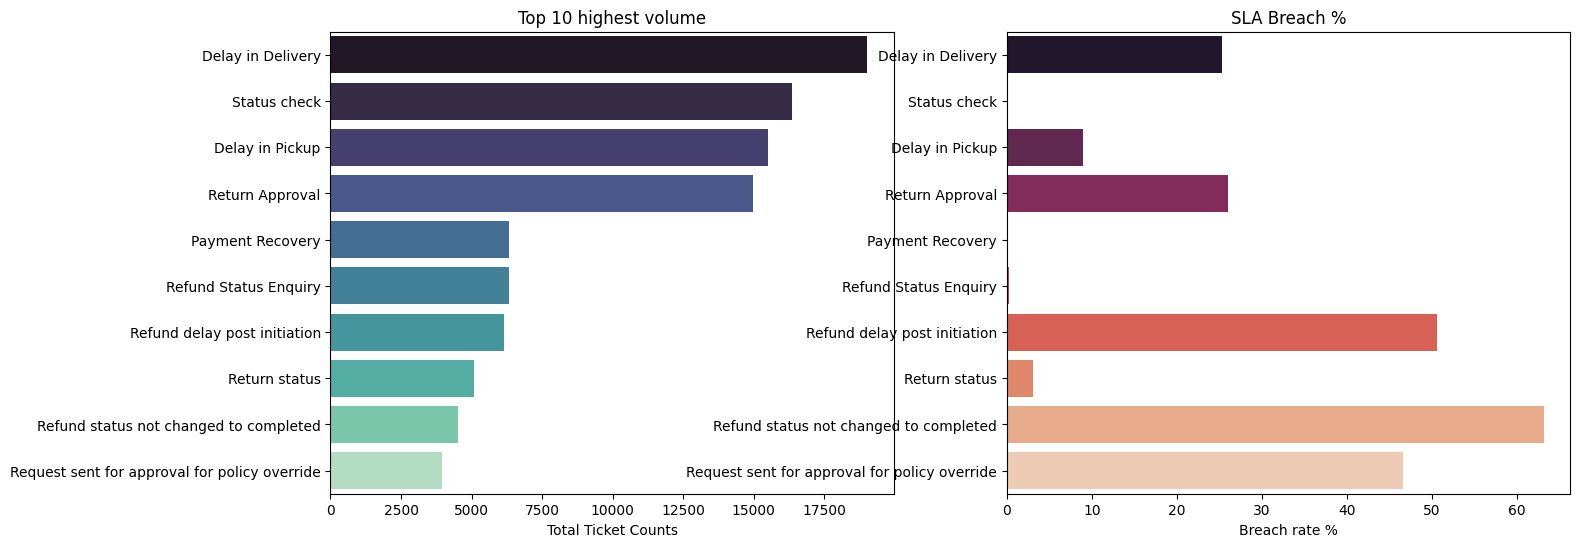

ETL Completed


In [0]:
raw_data.limit(2).toPandas()

clean_df = raw_data.fillna({
    "pain_in_mins":0,
    "incident_ijs_score": 0,
    "final_issue_type": "unknown",
    "resolution_deadline_breached":"No"
})

silver_df = clean_df \
    .withColumn("final_issue_type", trim(col("final_issue_type"))) \
    .withColumn("is_breached_int", when(col("resolution_deadline_breached")=="Breach",1).otherwise(0)) \
    .withColumn("pain_in_mins", col("pain_in_mins").cast("integer"))
print("Aggregating Metrics")

gold_summary_df = silver_df.groupby("final_issue_type").agg(
    count("incident_id").alias("total_tickets"),
    sum("is_breached_int").alias("total_breaches"),
    round(avg("pain_in_mins"),2).alias("avg_pain_minutes"),
    round(avg("incident_ijs_score"),2).alias("avg_ijs_score")
    )

gold_summary_df = gold_summary_df.withColumn(
    "breach_rate_pct",
    round((col("total_breaches")/col("total_tickets")) * 100,2)
)

gold_summary_df = gold_summary_df.filter(col("total_tickets")>20)
print("Saving to Lake Delta")

gold_summary_df.write.format("delta").mode("overwrite").saveAsTable("workspace.default.issue_bottleneck_summary")
print("Generating Visuals")

plot_df = gold_summary_df.orderBy(col("total_tickets").desc()).limit(10).toPandas()
fig, axes = plt.subplots(1,2, figsize=(16,6))

sns.barplot(data=plot_df, x='total_tickets', y='final_issue_type', hue="final_issue_type", palette='mako', legend=False, ax=axes[0])
axes[0].set_title("Top 10 highest volume")
axes[0].set_xlabel("Total Ticket Counts")
axes[0].set_ylabel('')

sns.barplot(data=plot_df, x='breach_rate_pct', y='final_issue_type',hue ="final_issue_type", palette='rocket', legend=False, ax=axes[1])
axes[1].set_title("SLA Breach %")
axes[1].set_xlabel("Breach rate %")
axes[1].set_ylabel('')

plt.show()
print("ETL Completed")